# The five stars, and their mean

Every rating is an integer from 1 to 5. The counts are

$$
\begin{aligned}
1 &\colon 6110 \\
2 &\colon 11370 \\
3 &\colon 27145 \\
4 &\colon 34174 \\
5 &\colon 21201
\end{aligned}
$$

They add to 100000. The weighted sum is the total of the stars:

$$
\begin{aligned}
1\cdot 6110 + 2\cdot 11370 + 3\cdot 27145 + 4\cdot 34174 + 5\cdot 21201
&= 352986 \\
\dfrac{352986}{100000} &= \dfrac{176493}{50000}
\end{aligned}
$$

So the mean rating is $176493/50000$, a little above $3.5$. The most common single star is 4, on 34174 ratings. The mean and the mode are not the same summary: the mean uses every star, and the mode is only the fullest bin.

A constant prediction of this mean is the squared-error baseline for the whole file. It is not yet a recommender. It gives the same number to every person and every movie.


In [2]:
# Locate the MovieLens tables beside this notebook, or under the course root.
from pathlib import Path

def data_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "16-Movie Recommendation" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "u.info").exists():
            return direct
    raise FileNotFoundError(name)

def read_lines(name):
    return data_path(name).read_text(encoding="latin-1").splitlines()

def read_ratings(name):
    rows = []
    for line in read_lines(name):
        if not line.strip():
            continue
        user, item, rating, stamp = line.split("\t")
        rows.append((int(user), int(item), int(rating), int(stamp)))
    return rows

ratings = read_ratings("u.data")
print(len(ratings), ratings[0])


100000 (196, 242, 3, 881250949)


In [3]:
# Count the five stars and reduce the mean.
from fractions import Fraction
from collections import Counter
counts = Counter(rating for _, _, rating, _ in ratings)
print(dict(sorted(counts.items())))
assert dict(counts) == {1: 6110, 2: 11370, 3: 27145, 4: 34174, 5: 21201}
assert sum(counts.values()) == 100000
total = sum(star * count for star, count in counts.items())
print(total, Fraction(total, 100000))
assert total == 352986
assert Fraction(total, 100000) == Fraction(176493, 50000)
assert counts[4] == max(counts.values())


{1: 6110, 2: 11370, 3: 27145, 4: 34174, 5: 21201}
352986 176493/50000


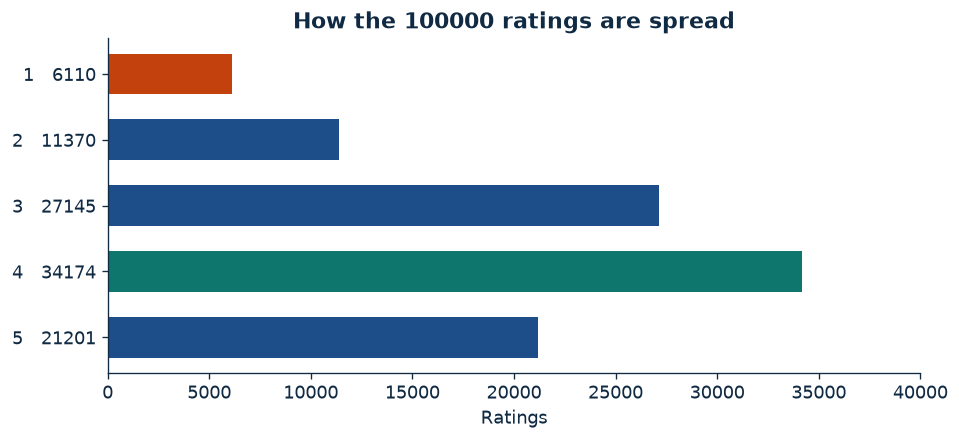

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
# Five bins, drawn from zero. Four stars is the fullest bin.
counts = [6110, 11370, 27145, 34174, 21201]
labels = [f"{star}   {count}" for star, count in zip(range(1, 6), counts)]
colors = ["#c2410c", "#1d4e89", "#1d4e89", "#0f766e", "#1d4e89"]
figure, axis = plt.subplots(figsize=(8.2, 3.8))
positions = [4, 3, 2, 1, 0]
axis.barh(positions, counts, color=colors, height=0.62)
axis.set_yticks(positions, labels)
axis.set_xlim(0, 40000)
axis.set_xlabel("Ratings")
axis.set_title("How the 100000 ratings are spread")
figure.tight_layout()


## Pitfall

The green bar is the mode, 4 stars, not the mean. The mean $176493/50000$ sits between 3 and 4. Predicting 4 for every rating because it is the fullest bin loses the squared-error comparison that the mean wins.

## Summary

6110 ones, 11370 twos, 27145 threes, 34174 fours, and 21201 fives. The stars sum to 352986. The mean is $176493/50000$.
